In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.signal import find_peaks
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import utils

In [2]:
HE_SHEET = "he test.xlsx"

df = pd.read_excel(HE_SHEET)
df_filtered = df[(df['nm'] >= 400) & (df['nm'] <= 750)].copy()

# Sort by 'nm' to ensure correct neighbor comparison and plotting order
df_filtered = df_filtered.sort_values(by='nm').reset_index(drop=True)

print("DataFrame loaded successfully. Here are the first 5 rows:")
print(df.head())

DataFrame loaded successfully. Here are the first 5 rows:
   Unnamed: 0  Grey Val         nm  Unnamed: 3    Unnamed: 4  Unnamed: 5  \
0        2178   247.148  589.03701         NaN  max grey val         NaN   
1        2179   246.463  587.91075         NaN       247.148         NaN   
2        2180   243.830  586.78449         NaN           NaN         NaN   
3        2181   241.833  585.65823         NaN  min grey val         NaN   
4        2177   240.733  590.16327         NaN        16.674         NaN   

   Unnamed: 6 Unnamed: 7  
0  3042.03129   -1.12626  
1         NaN        NaN  
2         NaN        NaN  
3         NaN        NaN  
4         NaN    he_3584  


In [3]:
min_grey_val = df_filtered['Grey Val'].min()
max_grey_val = df_filtered['Grey Val'].max()
grey_val_range = max_grey_val - min_grey_val

rgb = utils.wavelength_to_rgb

x_wavelengths = df_filtered['nm'].values 
z_intensity = df_filtered['Grey Val'].values 
spectral_colors = [rgb(nm) for nm in x_wavelengths]

x_title = 'Wavelength (nm)'
z_title = 'Intensity'
x_min = 400
x_max = 750
azim = -120
fig_size = (15,8)
mode = 'dark'

In [46]:
def axis_labels():
    if mode == 'dark':
        fig_bg = 'black'
        text = 'white'

    else:
        fig_bg = 'white'
        text = 'black'
    
    ax.set_xlabel(x_title, color=text)
    ax.set_ylabel('Arbitrary Y-coordinate (for 3D view)', color=fig_bg)
    ax.set_zlabel(z_title, color=text)
    ax.tick_params(axis='x', colors=text)
    ax.tick_params(axis='y', colors=fig_bg)
    ax.tick_params(axis='z', colors=text)

    ax.set_xlim(x_wavelengths.min(), x_wavelengths.max())
    ax.set_zlim(0, z_intensity.max() * 1.1)

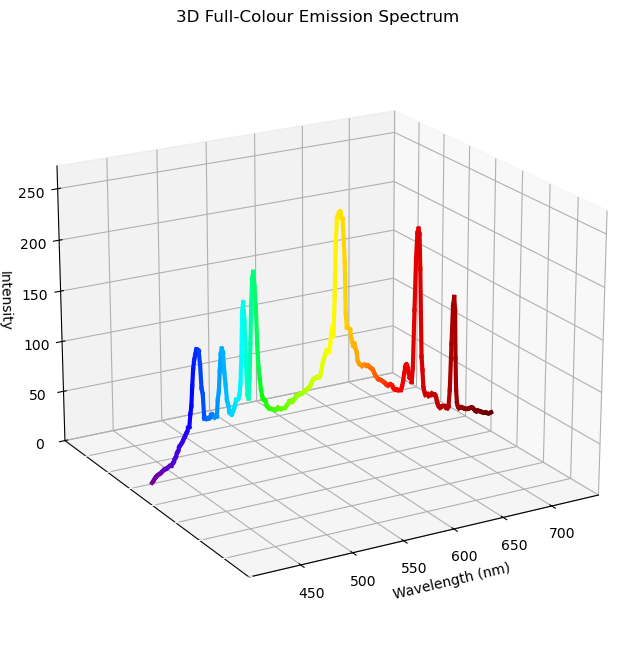

In [13]:
mode = 'light'

# Create segments for the 3D line collection
# Each segment is defined by two points: (x1, y1, z1) and (x2, y2, z2)
# For a simple 3D line, we can keep the y-coordinate constant or slightly vary it.
# Let's keep y constant for a single plane visualization initially.
y_coords = np.full_like(x_wavelengths, 0) # Constant y-coordinate for simplicity

# Prepare data for Line3DCollection
points = np.array([x_wavelengths, y_coords, z_intensity]).T.reshape(-1, 1, 3)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a Line3DCollection with the calculated colors
# We need to ensure colors match segments (N-1 colors for N points)
line_collection = LineCollection(segments[:, :, :2], colors=spectral_colors[:-1], linewidth=3) # Use xy for LineCollection

# Plotting the 3D line with colors
# LineCollection in 3D is a bit tricky, it often expects 2D data for coloring, 
# and we need to explicitly plot the z-component or use plot() for 3D lines.
# Let's use ax.plot for each segment for direct color mapping in 3D, 
# as Line3DCollection can be less intuitive with coloring.

for i in range(len(x_wavelengths) - 1):
    ax.plot(x_wavelengths[i:i+2], y_coords[i:i+2], z_intensity[i:i+2],
            color=spectral_colors[i], linewidth=3)

# Set labels and title
axis_labels()
ax.set_title('3D Full-Colour Emission Spectrum')

# Set limits to ensure good viewing
ax.set_xlim(x_wavelengths.min(), x_wavelengths.max())
ax.set_ylim(-1, 1) # Small range for arbitrary Y
ax.set_zlim(0, z_intensity.max() * 1.1) # Some padding for intensity

# Adjust view angle for better perspective
ax.view_init(elev=20, azim=-120) # Elevation and Azimuth angle

plt.show()


# Reset style to default after plotting to avoid affecting subsequent plots
plt.style.use('default')

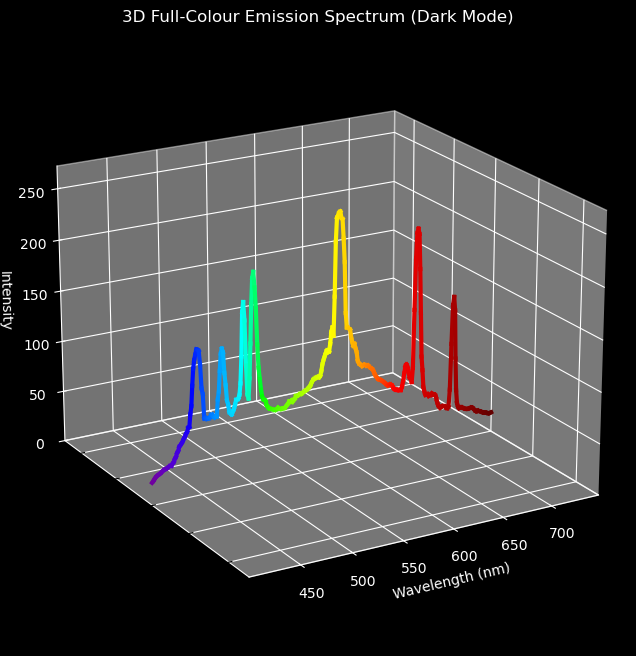

In [64]:
# Apply dark background style
mode = 'dark'
plt.style.use('dark_background')

# Create the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

y_coords = np.full_like(x_wavelengths, 0) # Constant y-coordinate for simplicity

for i in range(len(x_wavelengths) - 1):
    ax.plot(x_wavelengths[i:i+2], y_coords[i:i+2], z_intensity[i:i+2],
            color=spectral_colors[i], linewidth=3)

axis_labels()
ax.set_title('3D Full-Colour Emission Spectrum (Dark Mode)', color='white')

# Set limits to ensure good viewing
ax.set_ylim(-0.5, 0.5) # Small range for arbitrary Y

# Adjust view angle for better perspective
ax.view_init(elev=20, azim=-120) # Elevation and Azimuth angle

plt.show()


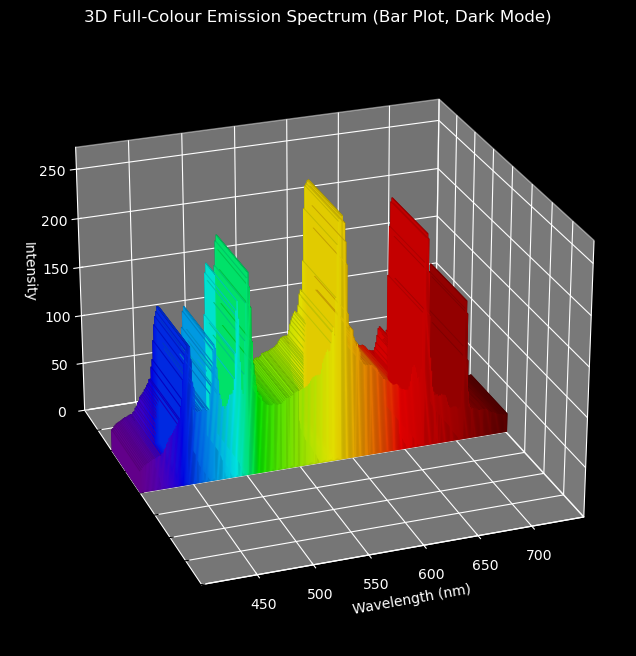

In [48]:
mode = 'dark'
# Apply dark background style
plt.style.use('dark_background')

# Create the 3D plot
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

# For bar3d, we need x, y, z coordinates for the base, and dx, dy, dz for dimensions.
# We'll make each bar a thin slice along the x-axis (wavelength).
# The y-coordinate will be constant (e.g., 0) to keep it in a single plane for this view.

dx = np.diff(x_wavelengths) # Width of each bar along x-axis
dx = np.append(dx, dx[-1]) # Assume last bar has same width as previous

dy = 0.5 # A fixed depth for the bars along y-axis
dy_arr = np.full_like(x_wavelengths, dy)

dz = z_intensity # Height of each bar along z-axis

xpos = x_wavelengths # x-position of the base of each bar
ypos = np.full_like(x_wavelengths, 0) # y-position of the base of each bar (constant)
zpos = np.zeros_like(z_intensity) # z-position of the base of each bar (ground level)

# Convert RGB tuples to a format usable by bar3d (list of RGBA or RGB)
# Alpha can be adjusted if needed, but for solid bars, 1.0 is fine.
facecolors = np.array(spectral_colors)

# Plotting the 3D bars
ax.bar3d(xpos, ypos, zpos, dx, dy_arr, dz, color=facecolors, shade=True)

# Set labels and title
axis_labels()
ax.set_title('3D Full-Colour Emission Spectrum (Bar Plot, Dark Mode)', color='white')

# Set limits to ensure good viewing
ax.set_ylim(-1, 1) # Small range around 0 for arbitrary depth

# Adjust view angle for better perspective
ax.view_init(elev=25, azim=-110) # Elevation and Azimuth angle2

plt.show()

# Reset style to default after plotting to avoid affecting subsequent plots
plt.style.use('default')


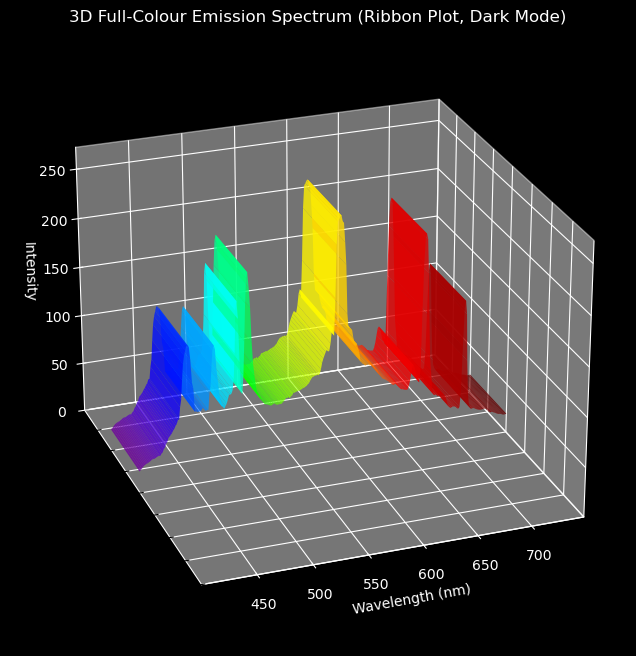

In [66]:
mode = 'dark'
# Apply dark background style
plt.style.use('dark_background')

# Create the 3D plot
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

# Define a small 'depth' for the ribbon
ribbon_depth = 0.5

polygons = []
for i in range(len(x_wavelengths) - 1):
    x1, x2 = x_wavelengths[i], x_wavelengths[i+1]
    z1, z2 = z_intensity[i], z_intensity[i+1]
    
    # Define the four corners of each rectangle (quad)
    # Point 1: (x1, 0, z1)
    # Point 2: (x2, 0, z2)
    # Point 3: (x2, ribbon_depth, z2)
    # Point 4: (x1, ribbon_depth, z1)
    # This creates a quad that extends from y=0 to y=ribbon_depth

    poly = [
        (x1, 0, z1),
        (x2, 0, z2),
        (x2, ribbon_depth, z2),
        (x1, ribbon_depth, z1)
    ]
    polygons.append(poly)

# Create a Poly3DCollection to draw the ribbon segments
# We use spectral_colors[:-1] because there are N-1 segments for N data points
ax.add_collection3d(Poly3DCollection(polygons, facecolors=spectral_colors[:-1], edgecolors='none', alpha=0.8))



# Set labels and title
ax.set_title('3D Full-Colour Emission Spectrum (Ribbon Plot, Dark Mode)', color='white')
axis_labels()

# Set limits to ensure good viewing
ax.set_ylim(-1, 1) # Adjust y-lim to see the ribbon


# Adjust view angle for better perspective
ax.view_init(elev=25, azim=-110) # Elevation and Azimuth angle

plt.show()

# Reset style to default after plotting to avoid affecting subsequent plots
plt.style.use('default')


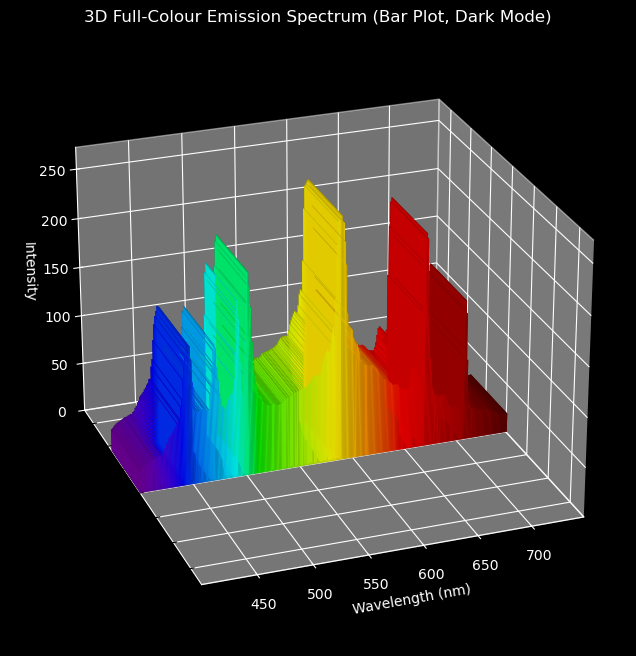

In [50]:
mode = 'dark'
# Apply dark background style
plt.style.use('dark_background')

# Create the 3D plot
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

# For a 3D bar plot, we need positions (x, y, z) and dimensions (dx, dy, dz)

# X-coordinates for the base of the bars
xpos = x_wavelengths

# Y-coordinates for the base of the bars (constant for a single spectrum)
ypos = np.full_like(x_wavelengths, 0)

# Z-coordinates for the base of the bars (always 0)
zpos = np.zeros_like(z_intensity)

# Width of bars along X-axis (dx)
# For non-uniform, a fixed small `dx` is better.
dx = np.diff(x_wavelengths).mean() * 0.8 if len(x_wavelengths) > 1 else 1.0 # 80% of average step

# Depth of bars along Y-axis (dy)
dy = dx # Make depth equal to width for cubic appearance

# Height of bars along Z-axis (dz) is the intensity
dz = z_intensity

# Plot the 3D bars
ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=spectral_colors, shade=True)

# Set labels and title
ax.set_title('3D Full-Colour Emission Spectrum (Bar Plot, Dark Mode)', color='white')

# Customize tick parameters for dark mode
axis_labels()

# Set limits to ensure good viewing
ax.set_ylim(-dy*2, dy*2) # Adjust y-lim to accommodate bar depth


# Adjust view angle for better perspective
ax.view_init(elev=25, azim=-110) # Elevation and Azimuth angle

plt.show()

# Reset style to default after plotting to avoid affecting subsequent plots
plt.style.use('default')


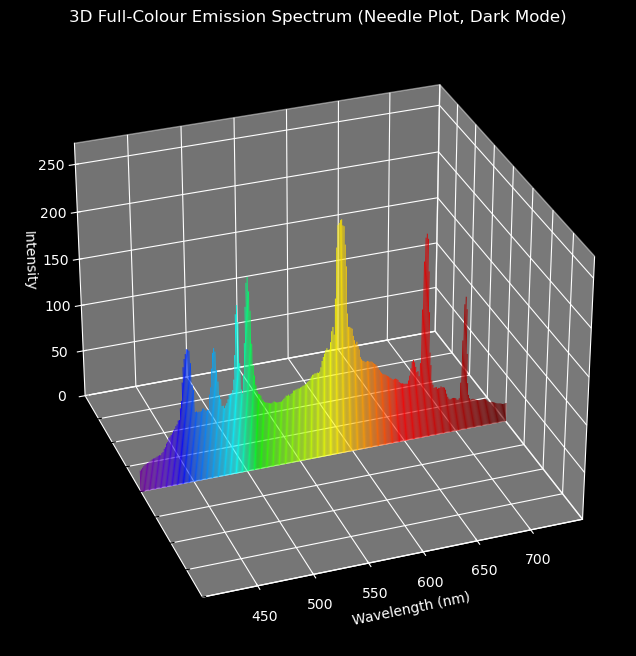

In [51]:
mode = 'dark'

# Apply dark background style for better contrast
plt.style.use('dark_background')

# Create the 3D plot
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

# For a 3D 'needle' plot, we want vertical lines originating from z=0.
# We can use a constant y-coordinate for a single spectrum.
y_constant = 0

# Plot each 'needle' individually
for i in range(len(x_wavelengths)): 
    ax.plot([x_wavelengths[i], x_wavelengths[i]], # x-coordinates for the line
            [y_constant, y_constant],           # y-coordinates for the line (constant)
            [0, z_intensity[i]],                # z-coordinates for the line (from 0 to intensity)
            color=spectral_colors[i], 
            linewidth=0.7, # Very thin line for the 'needle' effect
            alpha=0.9)

# Set labels and title
axis_labels()
ax.set_title('3D Full-Colour Emission Spectrum (Needle Plot, Dark Mode)', color='white')



# Set limits to ensure good viewing

ax.set_ylim(-1, 1) # Keep y-range small since it's a single plane


# Adjust view angle for better perspective on the 'needles'
ax.view_init(elev=30, azim=-110) # Elevation and Azimuth angle

plt.show()

# Reset style to default after plotting to avoid affecting subsequent plots
plt.style.use('default')


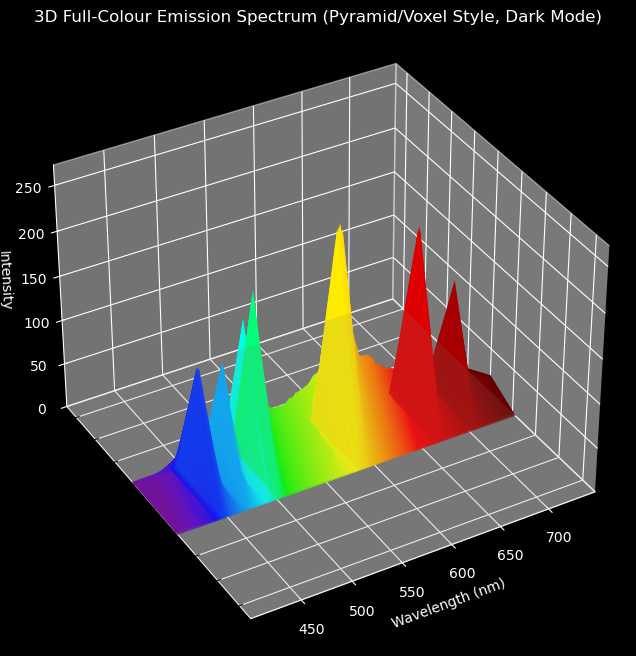

In [52]:
mode = 'dark'
# Apply dark background style for better contrast
plt.style.use('dark_background')

# Create the 3D plot
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

all_polygons = []
all_facecolors = []

# Parameters for the pyramid base
if len(x_wavelengths) > 1:
    avg_wavelength_step = np.mean(np.diff(x_wavelengths))
    base_size = avg_wavelength_step * 0.4 # Size of the pyramid base
else:
    base_size = 1.0

y_center = 0 # Y-coordinate for the center of the pyramid base

# Normalize intensity for pyramid height and potentially base size
max_intensity = z_intensity.max()
if max_intensity == 0:
    max_intensity = 1

# Scale heights for better visual representation
scaled_heights = (z_intensity / max_intensity) * max_intensity # Can adjust multiplier for visual scaling

for i in range(len(x_wavelengths)):
    x_val = x_wavelengths[i]
    z_val = scaled_heights[i]
    color = spectral_colors[i]

    if z_val > 0: # Only draw pyramids for non-zero intensity
        # Define the apex of the pyramid
        apex = [x_val, y_center, z_val]

        # Define the base vertices of the pyramid
        # These are points forming a square on the x-y plane at z=0
        base_v1 = [x_val - base_size/2, y_center - base_size/2, 0]
        base_v2 = [x_val + base_size/2, y_center - base_size/2, 0]
        base_v3 = [x_val + base_size/2, y_center + base_size/2, 0]
        base_v4 = [x_val - base_size/2, y_center + base_size/2, 0]

        # Define the 5 faces of the pyramid
        # Base face (square)
        face_base = [base_v1, base_v2, base_v3, base_v4]
        # Four triangular side faces
        face_side1 = [base_v1, base_v2, apex]
        face_side2 = [base_v2, base_v3, apex]
        face_side3 = [base_v3, base_v4, apex]
        face_side4 = [base_v4, base_v1, apex]

        all_polygons.extend([face_base, face_side1, face_side2, face_side3, face_side4])
        all_facecolors.extend([color] * 5) # Each pyramid has 5 faces, all same color

# Add all polygons to the 3D plot
ax.add_collection3d(Poly3DCollection(all_polygons, facecolors=all_facecolors, edgecolors='none', alpha=0.9))

# Add a subtle base plane for visual grounding
xx_plane, yy_plane = np.meshgrid(np.linspace(x_wavelengths.min() - base_size, x_wavelengths.max() + base_size, 2),
                                 np.linspace(y_center - base_size*2, y_center + base_size*2, 2))
zz_plane = np.zeros_like(xx_plane) # Flat plane at z=0
ax.plot_surface(xx_plane, yy_plane, zz_plane, alpha=0.15, color='gray', rstride=1, cstride=1, shade=False)

# Set labels and title
axis_labels()
ax.set_title('3D Full-Colour Emission Spectrum (Pyramid/Voxel Style, Dark Mode)', color='white')


# Set limits to ensure good viewing

ax.set_ylim(y_center - base_size*2, y_center + base_size*2)


# Adjust view angle for better perspective on the pyramids
ax.view_init(elev=35, azim=-120) # Elevation and Azimuth angle

plt.show()

# Reset style to default after plotting to avoid affecting subsequent plots
plt.style.use('default')


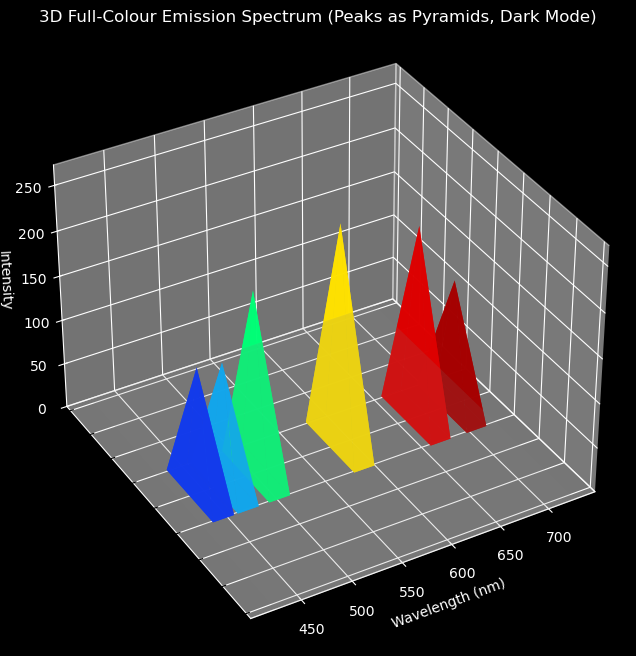

In [53]:
mode = 'dark'

# Apply dark background style for better contrast
plt.style.use('dark_background')

# --- Peak Detection ---
# Find peaks in the intensity data.
# 'distance' parameter ensures that peaks are sufficiently separated.
# 'prominence' parameter filters out minor fluctuations and focuses on significant peaks.
peaks, _ = find_peaks(z_intensity, prominence=z_intensity.max() * 0.1, distance=10) # Adjust prominence/distance as needed

# Filter the data to include only the peaks
peak_wavelengths = x_wavelengths[peaks]
peak_intensity = z_intensity[peaks]
peak_colors = [spectral_colors[i] for i in peaks]

# Create the 3D plot
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

all_polygons = []
all_facecolors = []

# Parameters for the pyramid base
if len(peak_wavelengths) > 1:
    # Calculate base size based on the average distance between peaks, or a fixed value
    avg_peak_wavelength_step = np.mean(np.diff(peak_wavelengths)) if len(peak_wavelengths) > 1 else 1.0
    base_size = avg_peak_wavelength_step * 0.4 # Size of the pyramid base
elif len(peak_wavelengths) == 1:
    base_size = 1.0 # Default for single peak
else:
    base_size = 0.5 # Fallback if no peaks found or very few

y_center = 0 # Y-coordinate for the center of the pyramid base

# Normalize intensity for pyramid height and potentially base size
max_intensity = peak_intensity.max() if len(peak_intensity) > 0 else 1
if max_intensity == 0:
    max_intensity = 1

# Scale heights for better visual representation
scaled_peak_heights = (peak_intensity / max_intensity) * max_intensity # Can adjust multiplier for visual scaling

for i in range(len(peak_wavelengths)):
    x_val = peak_wavelengths[i]
    z_val = scaled_peak_heights[i]
    color = peak_colors[i]

    if z_val > 0: # Only draw pyramids for non-zero intensity
        # Define the apex of the pyramid
        apex = [x_val, y_center, z_val]

        # Define the base vertices of the pyramid
        # These are points forming a square on the x-y plane at z=0
        base_v1 = [x_val - base_size/2, y_center - base_size/2, 0]
        base_v2 = [x_val + base_size/2, y_center - base_size/2, 0]
        base_v3 = [x_val + base_size/2, y_center + base_size/2, 0]
        base_v4 = [x_val - base_size/2, y_center + base_size/2, 0]

        # Define the 5 faces of the pyramid
        # Base face (square)
        face_base = [base_v1, base_v2, base_v3, base_v4]
        # Four triangular side faces
        face_side1 = [base_v1, base_v2, apex]
        face_side2 = [base_v2, base_v3, apex]
        face_side3 = [base_v3, base_v4, apex]
        face_side4 = [base_v4, base_v1, apex]

        all_polygons.extend([face_base, face_side1, face_side2, face_side3, face_side4])
        all_facecolors.extend([color] * 5) # Each pyramid has 5 faces, all same color

# Add all polygons to the 3D plot
ax.add_collection3d(Poly3DCollection(all_polygons, facecolors=all_facecolors, edgecolors='none', alpha=0.9))

# Add a subtle base plane for visual grounding
if len(peak_wavelengths) > 0:
    min_wl_peak, max_wl_peak = peak_wavelengths.min(), peak_wavelengths.max()
else:
    min_wl_peak, max_wl_peak = x_wavelengths.min(), x_wavelengths.max() # Use full range if no peaks

xx_plane, yy_plane = np.meshgrid(np.linspace(min_wl_peak - base_size, max_wl_peak + base_size, 2),
                                 np.linspace(y_center - base_size*2, y_center + base_size*2, 2))
zz_plane = np.zeros_like(xx_plane) # Flat plane at z=0
ax.plot_surface(xx_plane, yy_plane, zz_plane, alpha=0.15, color='gray', rstride=1, cstride=1, shade=False)

# Set labels and title
axis_labels()
ax.set_title('3D Full-Colour Emission Spectrum (Peaks as Pyramids, Dark Mode)', color='white')


# Set limits to ensure good viewing
ax.set_ylim(y_center - base_size*2, y_center + base_size*2)


# Adjust view angle for better perspective on the pyramids
ax.view_init(elev=35, azim=-120) # Elevation and Azimuth angle

plt.show()

# Reset style to default after plotting to avoid affecting subsequent plots
plt.style.use('default')